# Compare
Compare the uncertainty ellipses to the NHC 5-year average circles.

In [31]:
import glob
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
__author__ = "Randal J Barnes and Elizabeth A. Barnes"
__version__ = "15 December 2022"

In [33]:
NAME = "EARL"          # <<< adjustable parameter

ELLIPSE_COLOR = 'b'
CIRCLE_COLOR = 'r'
NAUTICAL_MILE_TO_KM = 1.852
FIGURE_WIDTH = 25

In [34]:
R = np.sqrt(-2.0 * (np.log(1.0 - 2.0/3.0)))

NHC2022 = {
    ('AL', 12): 26, ('AL', 24):  39, ('AL', 36):  52, ('AL', 48):   67,
    ('AL', 60): 84, ('AL', 72): 100, ('AL', 96): 142, ('AL', 120): 200,
}

In [35]:
THETA = np.linspace(0, 2 * np.pi, 1000)

def plot_circle(ax, radius):
    x = radius * np.cos(THETA)
    y = radius * np.sin(THETA)
    ax.plot(x, y, '-', color=CIRCLE_COLOR)

def plot_ellipse(ax, sigma_u, sigma_v, rho, r):
    x = r * sigma_u * np.cos(THETA)
    y = r * sigma_v * (rho * np.cos(THETA) + np.sqrt(1 - rho * rho) * np.sin(THETA))
    ax.plot(x, y, '-', color=ELLIPSE_COLOR)

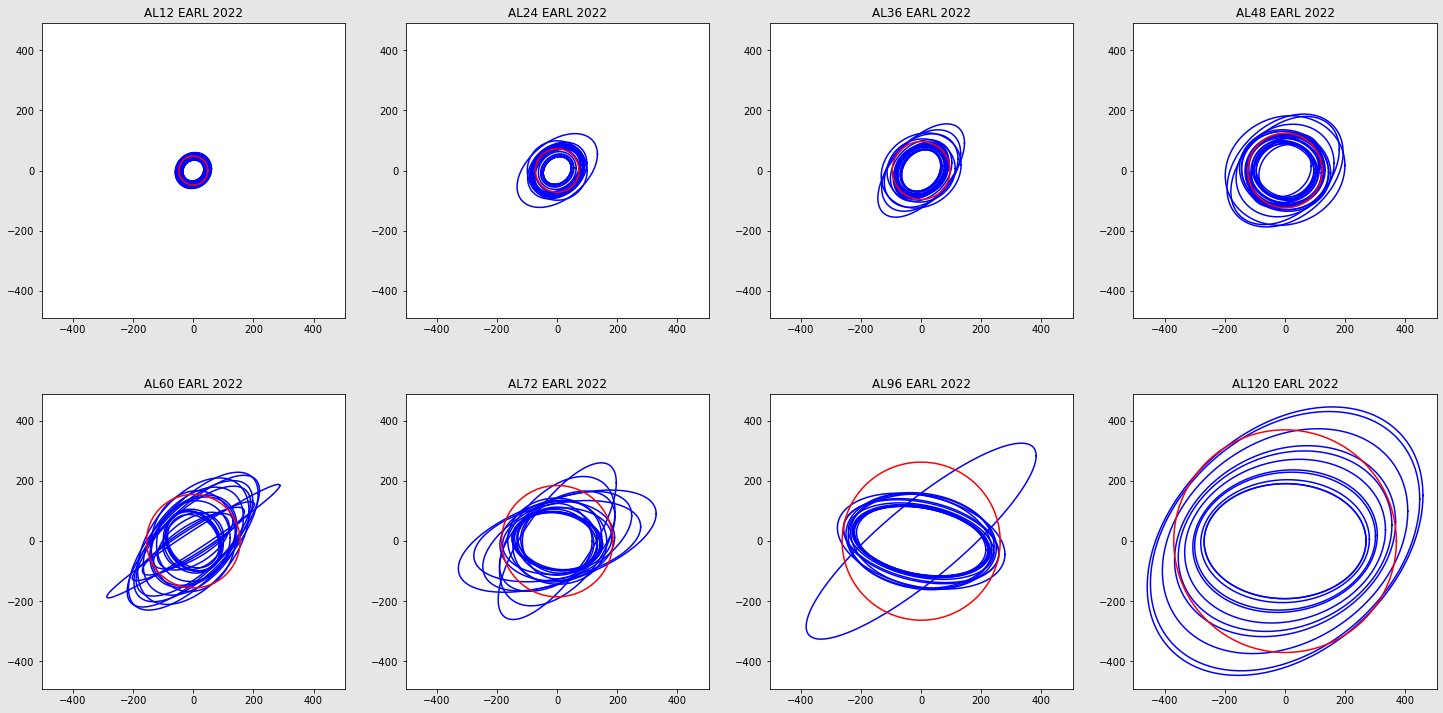

In [36]:
basin = 'AL'
ftimes = [12, 24, 36, 48, 60, 72, 96, 120]
year = 2022
rng_seed = 1

fig, ax = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(FIGURE_WIDTH, 0.5*FIGURE_WIDTH),
    facecolor=(0.9, 0.9, 0.9),
)
ax = ax.flat

for i, ftime in enumerate(ftimes):
    pathname = f"saved_predictions/centered_bivariate_normal_*_AL{ftime}_{year}_centered_bivariate_normal_rng_seed_{rng_seed}_testing_predictions.csv"
    file_list = glob.glob(pathname=pathname)
    assert(len(file_list) == 1)

    PREDICTIONS_FILE = file_list[0]
    predictions = pd.read_csv(PREDICTIONS_FILE)

    parameters = predictions.loc[predictions['Name']==NAME, ['time', 'sigma_u', 'sigma_v', 'rho']].copy()
    parameters.sort_values(by='time', inplace=True, ignore_index=True)

    for j, row in parameters.iterrows():
        plot_ellipse(ax[i], row['sigma_u'], row['sigma_v'], row['rho'], R)

    plot_circle(ax[i], NHC2022[(basin, ftime)]*NAUTICAL_MILE_TO_KM)

    ax[i].set_aspect('equal')
    ax[i].set_title(f"{basin}{ftime} {NAME} {year}")

# Set all the subplot axes limits equal.
all_left = all_right = all_top = all_bottom = 0.0

for i in range(len(ftimes)):
    left, right = ax[i].get_xlim()
    bottom, top = ax[i].get_ylim()

    all_left   = min(left, all_left)
    all_right  = max(right, all_right)
    all_bottom = min(bottom, all_bottom)
    all_top    = max(top, all_top)

for i in range(len(ftimes)):
    ax[i].set_xlim(all_left, all_right)
    ax[i].set_ylim(all_bottom, all_top)

plt.show()
